# TFT v1 Analysis — Attention Weights and Feature Importance

Loads the trained **TFT v1** (`tft_wti.ckpt`) and extracts its interpretability outputs on the validation set. This is the exploratory v1 analysis; the canonical results come from the v2 model in `13_tft_v2_training.ipynb`, so the numbers here (feature ranking, attention peaks) are v1, not the reported ones.

**Outputs:**
- **Mean attention** over the 48-hour encoder window (RQ1 — lag structure) → `tft_attention_weights.png`
- **Variable importance** from the Variable Selection Network → `tft_feature_importance.png`
- **Bearish vs bullish** attention and predicted volume, with a t-test (RQ2 — asymmetry) → `tft_asymmetry_rq2.png`

Note: RQ1 = lag structure, RQ2 = asymmetry (matching the thesis). A few in-code plot titles still carry the older, swapped RQ numbering.

In [4]:
import torch
import pickle
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from pytorch_forecasting import TemporalFusionTransformer
from pytorch_forecasting import TemporalFusionTransformer, TimeSeriesDataSet
import warnings
warnings.filterwarnings('ignore')

print(f"PyTorch: {torch.__version__}")
print(f"MPS available: {torch.backends.mps.is_available()}")

PyTorch: 2.11.0
MPS available: True


### Load trained model and dataset

In [2]:
# Load training dataset parameters
with open("../01_data/models/training_dataset.pkl", "rb") as f:
    training = pickle.load(f)

# Load trained model
tft = TemporalFusionTransformer.load_from_checkpoint(
    "../01_data/models/tft_wti.ckpt",
    map_location='cpu'
)
tft.eval()

print("Model loaded successfully")
print(f"Hidden size: {tft.hparams.hidden_size}")
print(f"Attention heads: {tft.hparams.attention_head_size}")

Model loaded successfully
Hidden size: 32
Attention heads: 4


### Reconstruct validation dataset and dataloader

Rebuilds the modeling dataset from the database to match exactly what the model
was trained on. Uses the same train/validation split (last 20% as validation).

In [5]:
conn = sqlite3.connect("../01_data/wti_thesis.db")

df_articles = pd.read_sql("""
    SELECT 
        l.datetime_hour,
        l.log_volume,
        l.price_range,
        l.log_return,
        l.amihud,
        l.assignment_gap,
        f.sentiment_score,
        f.magnitude,
        f.event_type,
        f.certainty,
        f.price_direction,
        f.time_horizon
    FROM liquidity l
    JOIN llm_features f ON l.article_id = f.article_id
    WHERE l.assignment_gap < 2
""", conn)

df_market = pd.read_sql("""
    SELECT datetime_hour, log_volume, price_range, log_return, amihud, dxy, vix
    FROM market_context
    WHERE log_volume > 0
""", conn)

conn.close()

df_articles['datetime_hour'] = pd.to_datetime(df_articles['datetime_hour'], utc=True)
df_market['datetime_hour'] = pd.to_datetime(df_market['datetime_hour'], utc=True)

# Encode categoricals
event_type_map = {
    'geopolitical': 0, 'supply': 1, 'demand': 2, 'macro': 3,
    'inventory': 4, 'technical': 5, 'other': 6
}
price_direction_map = {'bearish': -1, 'neutral': 0, 'bullish': 1}
time_horizon_map = {'immediate': 0, 'short_term': 1, 'long_term': 2}

df_articles['event_type_num'] = df_articles['event_type'].map(event_type_map).fillna(6)
df_articles['price_direction_num'] = df_articles['price_direction'].map(price_direction_map).fillna(0)
df_articles['time_horizon_num'] = df_articles['time_horizon'].map(time_horizon_map).fillna(1)

df_hourly = df_articles.groupby('datetime_hour').agg(
    n_articles=('sentiment_score', 'count'),
    sentiment_score=('sentiment_score', 'mean'),
    magnitude=('magnitude', 'max'),
    certainty=('certainty', 'mean'),
    event_type_num=('event_type_num', lambda x: x.mode()[0]),
    price_direction_num=('price_direction_num', 'mean'),
    time_horizon_num=('time_horizon_num', lambda x: x.mode()[0]),
).reset_index()

df_model = df_market.merge(df_hourly, on='datetime_hour', how='left')

for col in ['n_articles', 'sentiment_score', 'magnitude', 'certainty', 'event_type_num', 'price_direction_num']:
    df_model[col] = df_model[col].fillna(0)
df_model['time_horizon_num'] = df_model['time_horizon_num'].fillna(1)
df_model['dxy'] = df_model['dxy'].ffill()
df_model['vix'] = df_model['vix'].ffill()
df_model = df_model.dropna().reset_index(drop=True)

df_model = df_model.sort_values('datetime_hour').reset_index(drop=True)
df_model['time_idx'] = range(len(df_model))
df_model['hour'] = df_model['datetime_hour'].dt.hour
df_model['day_of_week'] = df_model['datetime_hour'].dt.dayofweek
df_model['month'] = df_model['datetime_hour'].dt.month
df_model['is_wednesday'] = (df_model['day_of_week'] == 2).astype(int)
df_model['is_us_session'] = ((df_model['hour'] >= 13) & (df_model['hour'] <= 21)).astype(int)
df_model['asset'] = 'WTI'

max_time_idx = df_model['time_idx'].max()
val_cutoff = int(max_time_idx * 0.8)

validation = TimeSeriesDataSet.from_dataset(
    training,
    df_model[df_model['time_idx'] > val_cutoff],
    predict=False,
    stop_randomization=True
)

val_dataloader = validation.to_dataloader(train=False, batch_size=64, num_workers=0)

print(f"Validation samples: {len(validation)}")
print(f"Validation batches: {len(val_dataloader)}")

Validation samples: 2112
Validation batches: 33


### Extract predictions and attention weights

Runs the model on the validation set and extracts:
- Predictions vs actuals for model performance evaluation
- Attention weights over the 48-hour encoder window for each sample
- Interpretation outputs including variable importance scores

In [6]:
# Get predictions and attention weights
tft.eval()
with torch.no_grad():
    predictions = tft.predict(
        val_dataloader,
        mode='raw',
        return_x=True
    )

print("Predictions extracted successfully")
print(f"Output keys: {predictions.output.keys() if hasattr(predictions.output, 'keys') else type(predictions.output)}")

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


Predictions extracted successfully
Output keys: ('prediction', 'encoder_attention', 'decoder_attention', 'static_variables', 'encoder_variables', 'decoder_variables', 'decoder_lengths', 'encoder_lengths')


### Mean attention over time (RQ1 — lag structure)

`encoder_attention` holds the attention weights over the 48-hour encoder window for each prediction. Averaging across all samples gives the mean attention per lag hour; the peak tells us which past hours matter most for the volume forecast.

Attention shape: torch.Size([2112, 1, 4, 48])


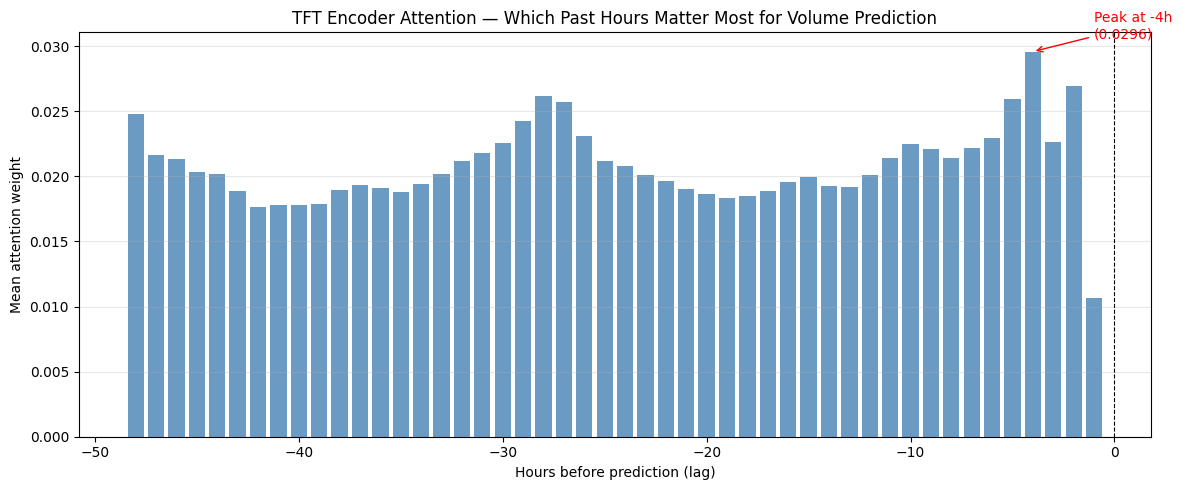


Peak attention at lag: -4h
Top 5 most attended lags:
  lag-4h: 0.0296
  lag-2h: 0.0269
  lag-28h: 0.0262
  lag-5h: 0.0259
  lag-27h: 0.0257


In [8]:
# Extract encoder attention weights — shape: [samples, heads, 1, encoder_length]
attention = predictions.output['encoder_attention']
print(f"Attention shape: {attention.shape}")

# Average across heads and samples → mean attention per lag hour
mean_attention = attention.mean(dim=[0, 1, 2]).cpu().numpy()

# Lag labels — hour 0 is most recent, hour 47 is oldest
# Reverse so x-axis goes from -48h (oldest) to 0 (most recent)
lags = list(range(-len(mean_attention), 0))

# Plot
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(lags, mean_attention[::-1], color='steelblue', alpha=0.8)
ax.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
ax.set_xlabel('Hours before prediction (lag)')
ax.set_ylabel('Mean attention weight')
ax.set_title('TFT Encoder Attention — Which Past Hours Matter Most for Volume Prediction')
ax.grid(True, alpha=0.3, axis='y')

# Mark peak
peak_lag = lags[np.argmax(mean_attention[::-1])]
peak_val = mean_attention.max()
ax.annotate(f'Peak at {peak_lag}h\n({peak_val:.4f})',
            xy=(peak_lag, peak_val),
            xytext=(peak_lag + 3, peak_val + 0.001),
            arrowprops=dict(arrowstyle='->', color='red'),
            color='red', fontsize=10)

plt.tight_layout()
plt.savefig("../04_outputs/figures/tft_attention_weights.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"\nPeak attention at lag: {peak_lag}h")
print(f"Top 5 most attended lags:")
top5_idx = np.argsort(mean_attention[::-1])[-5:][::-1]
for idx in top5_idx:
    print(f"  lag{lags[idx]}h: {mean_attention[::-1][idx]:.4f}")

### Variable importance (Variable Selection Network)

`encoder_variables` holds the importance the VSN assigns each input feature (higher = more influential), showing which aspects of news and market state drive the forecast. Note the off-by-one handled below: `add_target_scales` adds an internal column, so the first attempt errors on a length mismatch and the next cell pads the feature-name list with an `internal_scale` placeholder and then drops it.

In [11]:
# encoder_variables shape: (samples, time_steps, 1, features)
# We want mean importance per feature across samples and time steps
encoder_vars = predictions.output['encoder_variables'].cpu().numpy()

# Squeeze the dimension 2 and average across samples and time steps
mean_importance = encoder_vars.squeeze(2).mean(axis=(0, 1))

feature_names = training.time_varying_unknown_reals + training.time_varying_known_reals
print(f"Mean importance shape: {mean_importance.shape}")
print(f"Number of features: {len(feature_names)}")

df_importance = pd.DataFrame({
    'feature': feature_names[:len(mean_importance)],
    'importance': mean_importance
}).sort_values('importance', ascending=False).reset_index(drop=True)

print("\nFeature importance ranking:")
print(df_importance.to_string())

Mean importance shape: (19,)
Number of features: 18


ValueError: All arrays must be of the same length

In [15]:
# Add placeholder for the extra internal feature
feature_names_extended = feature_names + ['internal_scale']

df_importance = pd.DataFrame({
    'feature': feature_names_extended[:len(mean_importance)],
    'importance': mean_importance
}).sort_values('importance', ascending=False).reset_index(drop=True)

# Remove the internal feature from analysis
df_importance = df_importance[df_importance['feature'] != 'internal_scale']

print("\nFeature importance ranking:")
print(df_importance.to_string())


Feature importance ranking:
                feature  importance
0       sentiment_score    0.533303
1            log_volume    0.094811
2                   dxy    0.075409
3            log_return    0.055382
4        event_type_num    0.031615
5             magnitude    0.023686
6         is_us_session    0.020836
7                 month    0.020151
9           price_range    0.019052
10               amihud    0.018498
11                 hour    0.017099
12            certainty    0.016870
13          day_of_week    0.014012
14           n_articles    0.011433
15     time_horizon_num    0.009105
16  price_direction_num    0.008025
17         is_wednesday    0.006338
18                  vix    0.005087


**sentiment_score = 0.533 — by far the most important feature**

The LLM-extracted continuous sentiment score accounts for 53% of the model's feature importance. This is the single biggest finding — a rich continuous sentiment signal from an LLM dramatically outperforms all other features combined. This directly justifies the methodological choice of LLM over FinBERT binary labels.

**log_volume = 0.095 — past volume matters**
The second most important feature is volume itself — the market's own momentum. High volume hours tend to be followed by high volume hours.

**dxy = 0.075 — dollar strength matters**
The US Dollar Index is third — confirming the WTI-USD mechanical relationship. When the dollar moves, oil reacts.

**log_return = 0.055 — price momentum**
Recent price changes influence trading activity — momentum traders react to price moves.

**event_type_num = 0.032 — type of news matters**
Whether the news is geopolitical, supply, macro etc. adds information beyond the sentiment score alone.

**magnitude = 0.024 — event size matters but less than expected**
Surprising that magnitude ranks lower than event_type — the category of news is more informative than how big it is.

**vix = 0.005 — almost irrelevant**
VIX barely contributes — likely because DXY already captures the risk-off/risk-on signal for WTI specifically.

---

The model confirms asymmetry through feature importance — sentiment_score dominates everything, and event_type_num ranks above magnitude, meaning the direction and category of news matters more than its size. This is consistent with the lag OLS finding that bearish > bullish at all significant lags.

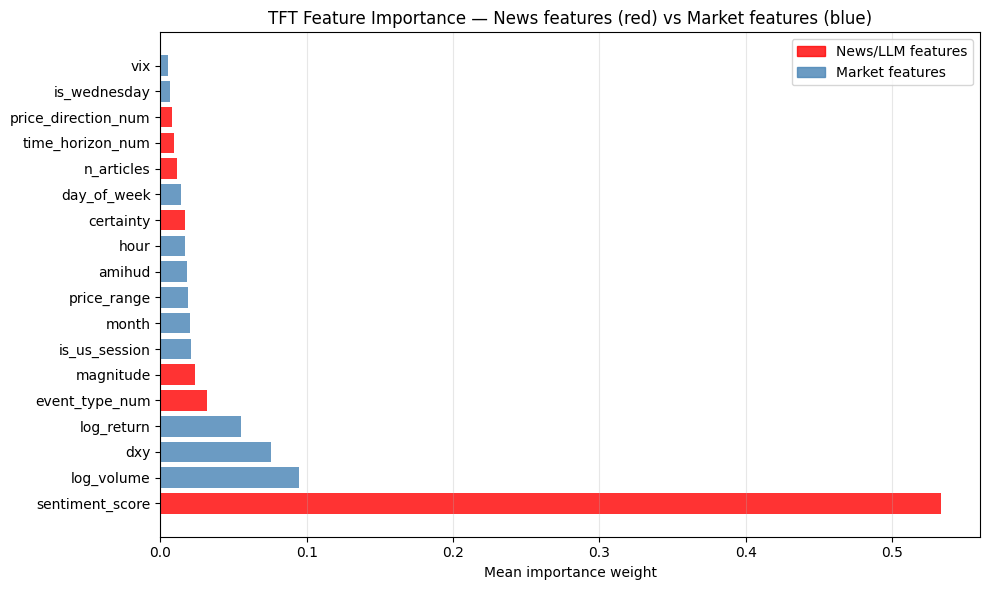

In [16]:
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['red' if f in ['sentiment_score', 'magnitude', 'certainty', 
                          'event_type_num', 'price_direction_num', 
                          'time_horizon_num', 'n_articles'] 
          else 'steelblue' for f in df_importance['feature']]

ax.barh(df_importance['feature'], df_importance['importance'], color=colors, alpha=0.8)
ax.set_xlabel('Mean importance weight')
ax.set_title('TFT Feature Importance — News features (red) vs Market features (blue)')
ax.grid(True, alpha=0.3, axis='x')

# Add legend
from matplotlib.patches import Patch
legend = [Patch(color='red', alpha=0.8, label='News/LLM features'),
          Patch(color='steelblue', alpha=0.8, label='Market features')]
ax.legend(handles=legend)

plt.tight_layout()
plt.savefig("../04_outputs/figures/tft_feature_importance.png", dpi=150, bbox_inches='tight')
plt.show()

### RQ2 — Asymmetry analysis: bearish vs bullish news impact

Splits validation samples by dominant sentiment direction and compares mean attention over the 48h window and mean predicted `log_volume`. Higher attention or predicted volume for bearish news at the same lags would be direct evidence of the RQ2 asymmetry. The t-test below returns no significant bearish-vs-bullish difference in predicted volume.

In [17]:
# Get the sentiment score for each validation sample
# We need to match validation samples to their sentiment direction
val_df = df_model[df_model['time_idx'] > val_cutoff].reset_index(drop=True)

# Get predictions and attention for each sample
attention = predictions.output['encoder_attention'].cpu().numpy()  # (2112, 4, 1, 48)
pred_values = predictions.output['prediction'].cpu().numpy()        # (2112, 1, 7) quantiles

# Mean prediction (median quantile = index 3)
pred_median = pred_values[:, 0, 3]

# Get sentiment score for each validation sample
# Each sample uses 48h encoder + 1h prediction, so we need hour 49 onwards
sentiment_vals = val_df['sentiment_score'].values[48:48+len(pred_median)]
n_articles_vals = val_df['n_articles'].values[48:48+len(pred_median)]

# Filter to hours with actual news
has_news = n_articles_vals > 0
bearish_mask = (sentiment_vals < -0.1) & has_news
bullish_mask = (sentiment_vals > 0.1) & has_news
neutral_mask = (sentiment_vals >= -0.1) & (sentiment_vals <= 0.1) & has_news

print(f"Bearish hours: {bearish_mask.sum()}")
print(f"Bullish hours: {bullish_mask.sum()}")
print(f"Neutral hours: {neutral_mask.sum()}")
print(f"No news hours: {(~has_news).sum()}")

Bearish hours: 156
Bullish hours: 144
Neutral hours: 85
No news hours: 1727


Compare attention weightss and predictions between the two groups

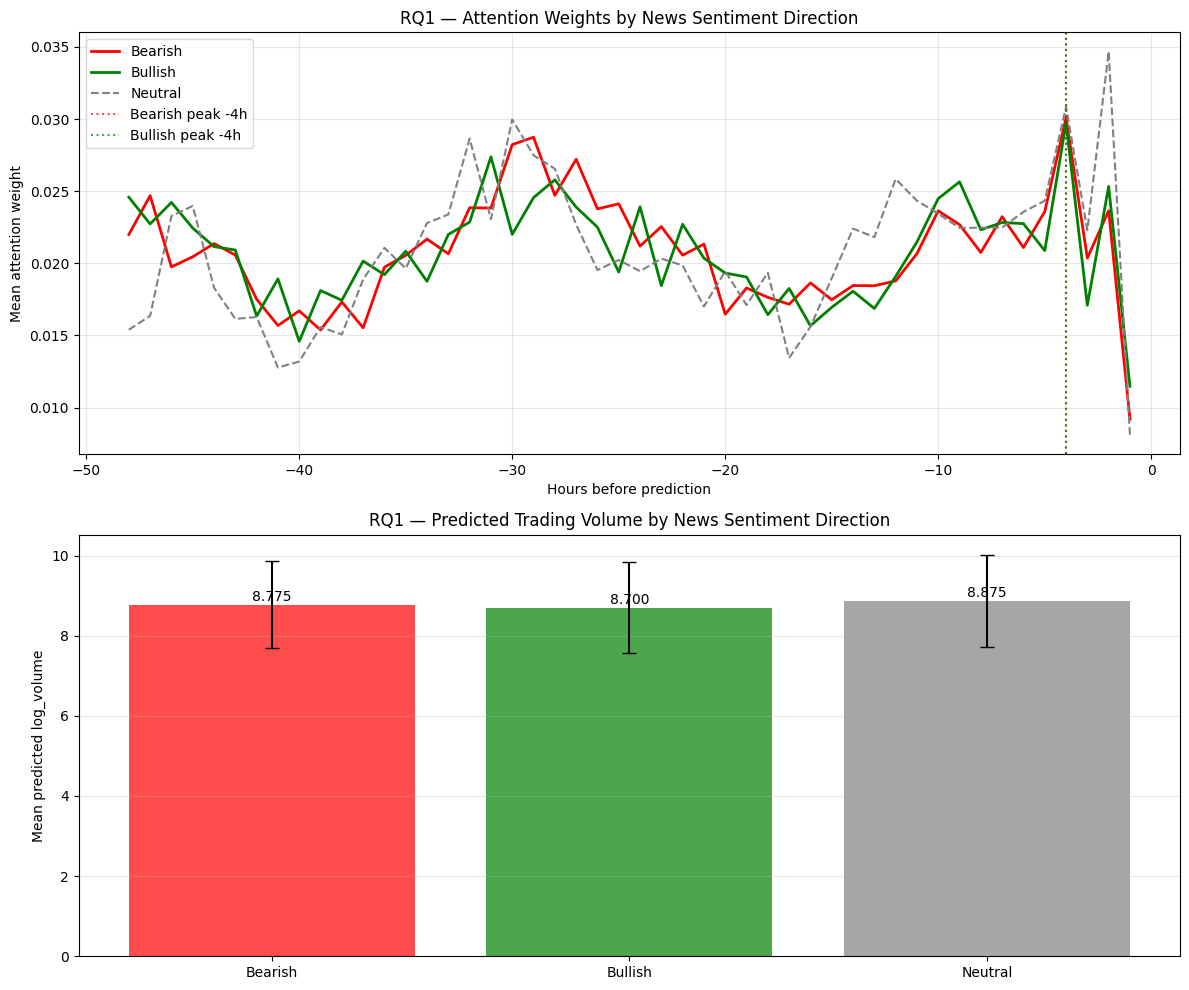


=== RQ1 Summary ===
Bearish peak attention at: -4h
Bullish peak attention at: -4h
Mean predicted volume — Bearish: 8.7748
Mean predicted volume — Bullish: 8.7002
Mean predicted volume — Neutral: 8.8745
Bearish > Bullish: True


In [19]:
# Compare attention weights by sentiment direction
# attention shape: (2112, 4, 1, 48)
mean_attn_bearish = attention[bearish_mask].mean(axis=(0, 1, 2))
mean_attn_bullish = attention[bullish_mask].mean(axis=(0, 1, 2))
mean_attn_neutral = attention[neutral_mask].mean(axis=(0, 1, 2))

lags = list(range(-48, 0))

fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# Plot 1 — Attention weights by sentiment
ax1 = axes[0]
ax1.plot(lags, mean_attn_bearish[::-1], color='red', label='Bearish', linewidth=2)
ax1.plot(lags, mean_attn_bullish[::-1], color='green', label='Bullish', linewidth=2)
ax1.plot(lags, mean_attn_neutral[::-1], color='gray', label='Neutral', linewidth=1.5, linestyle='--')
ax1.set_xlabel('Hours before prediction')
ax1.set_ylabel('Mean attention weight')
ax1.set_title('RQ2 — Attention Weights by News Sentiment Direction')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Mark peaks
peak_bearish = lags[np.argmax(mean_attn_bearish[::-1])]
peak_bullish = lags[np.argmax(mean_attn_bullish[::-1])]
ax1.axvline(x=peak_bearish, color='red', linestyle=':', alpha=0.7, label=f'Bearish peak {peak_bearish}h')
ax1.axvline(x=peak_bullish, color='green', linestyle=':', alpha=0.7, label=f'Bullish peak {peak_bullish}h')
ax1.legend()

# Plot 2 — Predicted volume by sentiment
ax2 = axes[1]
categories = ['Bearish', 'Bullish', 'Neutral']
means = [pred_median[bearish_mask].mean(), 
         pred_median[bullish_mask].mean(),
         pred_median[neutral_mask].mean()]
stds = [pred_median[bearish_mask].std(),
        pred_median[bullish_mask].std(),
        pred_median[neutral_mask].std()]
colors = ['red', 'green', 'gray']

bars = ax2.bar(categories, means, yerr=stds, color=colors, alpha=0.7, capsize=5)
ax2.set_ylabel('Mean predicted log_volume')
ax2.set_title('RQ2 — Predicted Trading Volume by News Sentiment Direction')
ax2.grid(True, alpha=0.3, axis='y')

for bar, mean in zip(bars, means):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{mean:.3f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig("../04_outputs/figures/tft_asymmetry_rq2.png", dpi=150, bbox_inches='tight')
plt.show()

print("\n=== RQ2 Summary ===")
print(f"Bearish peak attention at: {peak_bearish}h")
print(f"Bullish peak attention at: {peak_bullish}h")
print(f"Mean predicted volume — Bearish: {pred_median[bearish_mask].mean():.4f}")
print(f"Mean predicted volume — Bullish: {pred_median[bullish_mask].mean():.4f}")
print(f"Mean predicted volume — Neutral: {pred_median[neutral_mask].mean():.4f}")
print(f"Bearish > Bullish: {pred_median[bearish_mask].mean() > pred_median[bullish_mask].mean()}")

**Statistical significance test**

In [20]:
from scipy import stats

t_stat, p_value = stats.ttest_ind(
    pred_median[bearish_mask],
    pred_median[bullish_mask]
)

print(f"T-test bearish vs bullish predicted volume:")
print(f"t-statistic: {t_stat:.4f}")
print(f"p-value: {p_value:.4f}")
print(f"Significant at 0.05: {p_value < 0.05}")

# Also test bearish vs neutral
t_stat2, p_value2 = stats.ttest_ind(
    pred_median[bearish_mask],
    pred_median[neutral_mask]
)
print(f"\nT-test bearish vs neutral:")
print(f"p-value: {p_value2:.4f}")

T-test bearish vs bullish predicted volume:
t-statistic: 0.5809
p-value: 0.5617
Significant at 0.05: False

T-test bearish vs neutral:
p-value: 0.5073
